In [40]:
!pip install lime


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [41]:
!tail -57 data/spambase/spambase.names | cut -d ':' -f1 | paste -sd, - > ./data/spambase/names.csv
!sed -i ' 1 s/.*/&,is_spam/' ./data/spambase/names.csv

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import mean_squared_error
import numpy as np
import shap
from sklearn.metrics import accuracy_score

In [43]:
df = pd.read_csv("./data/spambase/names.csv")
data = pd.read_csv("./data/spambase/spambase.data", header=None)
df = pd.DataFrame(data.values, columns=df.columns)
df

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61.0,278.0,1.0
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101.0,1028.0,1.0
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485.0,2259.0,1.0
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40.0,191.0,1.0
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40.0,191.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3.0,88.0,0.0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4.0,14.0,0.0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6.0,118.0,0.0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5.0,78.0,0.0


In [44]:
X = df.drop("is_spam", axis=1)
y = df["is_spam"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)#, stratify=y)

In [46]:
clf = GradientBoostingClassifier (n_estimators =100, random_state =10)
clf.fit (X_train.values, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [47]:
X_train

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
1370,0.09,0.00,0.09,0.0,0.39,0.09,0.09,0.00,0.19,0.29,...,0.0,0.000,0.139,0.000,0.310,0.155,0.00,6.813,494.0,1458.0
3038,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.124,0.124,0.000,0.000,0.000,0.00,1.800,8.0,45.0
2361,0.00,0.00,2.43,0.0,0.00,0.00,0.00,0.00,0.27,0.00,...,0.0,0.000,0.344,0.000,0.000,0.000,0.00,2.319,12.0,167.0
156,0.00,0.00,0.00,0.0,1.31,0.00,1.31,1.31,1.31,1.31,...,0.0,0.000,0.000,0.000,0.117,0.117,0.00,48.500,186.0,291.0
2526,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.000,0.000,0.000,0.000,0.00,2.307,8.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.122,0.081,0.000,0.000,0.04,3.891,70.0,323.0
466,0.00,0.23,0.00,0.0,0.23,0.47,0.00,0.47,0.00,0.95,...,0.0,0.000,0.121,0.040,0.000,0.040,0.00,3.780,55.0,189.0
3092,0.00,0.00,0.00,0.0,1.49,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.229,0.000,0.000,0.000,0.00,2.333,10.0,49.0
3772,0.00,0.23,0.00,0.0,0.00,0.23,0.00,0.46,0.00,0.00,...,0.0,0.063,0.063,0.000,0.159,0.000,0.00,1.616,13.0,173.0


In [48]:
y_pred = clf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', mse)

# Initialize the explainer
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['no_spam', 'spam'],
    mode='classification',
    discretize_continuous=True
)
# Explain a prediction
i = 22 # index of the instance to be explained
exp = explainer_lime.explain_instance(data_row=X_test.values[i], predict_fn=clf.predict_proba, num_features=X_train.shape[1])


# Print the explanation
print('Instance:', i)
print('Prediction:', y_pred[i])
from IPython.display import HTML
display(HTML(exp.as_html()))
#exp.show_in_notebook(show_table=True)
exp.as_list()

Mean Squared Error: 0.05537459283387622
Instance: 22
Prediction: 1.0


/home/juanes/Escritorio/CLASE/master_trabajos/xai/trabajo1/IAExplicable_Proyectos/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


[('word_freq_george <= 0.00', 0.331096799231627),
 ('word_freq_hp <= 0.00', 0.29504441410580506),
 ('word_freq_remove <= 0.00', -0.2774928121799525),
 ('char_freq_! > 0.31', 0.22459731549032483),
 ('word_freq_edu <= 0.00', 0.22453922784175329),
 ('char_freq_$ > 0.05', 0.15695312529441466),
 ('word_freq_meeting <= 0.00', 0.1369892677624325),
 ('word_freq_free <= 0.00', -0.13254685093428992),
 ('capital_run_length_average > 3.71', 0.10254251955315535),
 ('word_freq_font <= 0.00', -0.10182925669469166),
 ('word_freq_000 <= 0.00', -0.09748263445825986),
 ('word_freq_our <= 0.00', -0.08678669978514794),
 ('word_freq_3d <= 0.00', -0.07840666699696336),
 ('word_freq_re > 0.12', -0.07183578879552029),
 ('word_freq_1999 <= 0.00', 0.07123210106892701),
 ('word_freq_business <= 0.00', -0.07101289511252265),
 ('word_freq_conference <= 0.00', 0.07031972345113478),
 ('word_freq_project <= 0.00', 0.06898112654669467),
 ('word_freq_money <= 0.00', -0.06705964495580416),
 ('14.00 < capital_run_length_l

### (a)

Aplicar técnicas de explicabilidad (por ejemplo, SHAP o LIME) al modelo entrenado y obtener un ranking de las características según su importancia. Representar gráficamente los resultados obtenidos.


In [49]:
def global_lime_importance(clf, explainer_lime, X_test, class_idx=1, n_instances=None):
    """
    Devuelve:
      I          -> importancias globales (vector)
      order_idx  -> índices de features ordenadas (desc)
    """
    if n_instances is None or n_instances > len(X_test):
        n_instances = len(X_test)

    X_sub = X_test.iloc[:n_instances]
    n_features = X_sub.shape[1]
    W = np.zeros((n_instances, n_features))

    for i in range(n_instances):
        exp = explainer_lime.explain_instance(
            X_sub.iloc[i].values,
            clf.predict_proba,
            num_features=n_features
        )
        for feat_idx, w in exp.local_exp[class_idx]:
            W[i, feat_idx] = w

    I = np.sqrt(np.sum(W**2, axis=0))          # I_j = sqrt(sum_i W_ij^2)
    order_idx = np.argsort(-I)                 # orden descendente

    return I, order_idx


In [50]:
I_lime, order_idx_lime = global_lime_importance(clf, explainer_lime, X_test)

# Por ejemplo, top-10 features
feature_names = X_test.columns.to_numpy()
for j in order_idx_lime[:10]:
    print(feature_names[j], I_lime[j])

word_freq_george 9.964302123540731
word_freq_hp 8.891540018200256
word_freq_remove 8.565689300927577
word_freq_edu 6.098946636855999
char_freq_! 4.682666161943923
char_freq_$ 4.309559953648773
word_freq_free 3.8895039617539915
word_freq_meeting 3.8663863369300855
word_freq_font 3.1976167836936322
word_freq_000 2.8743422648207297


In [51]:
# background: unos cuantos ejemplos de TRAIN
#background = X_train.sample(1000, random_state=10)
background = X_train

explainer_shap = shap.TreeExplainer(clf, background)

# explicaciones sobre TEST
shap_values = explainer_shap.shap_values(X_test)

In [52]:
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]   # clase 1
else:
    shap_values_pos = shap_values


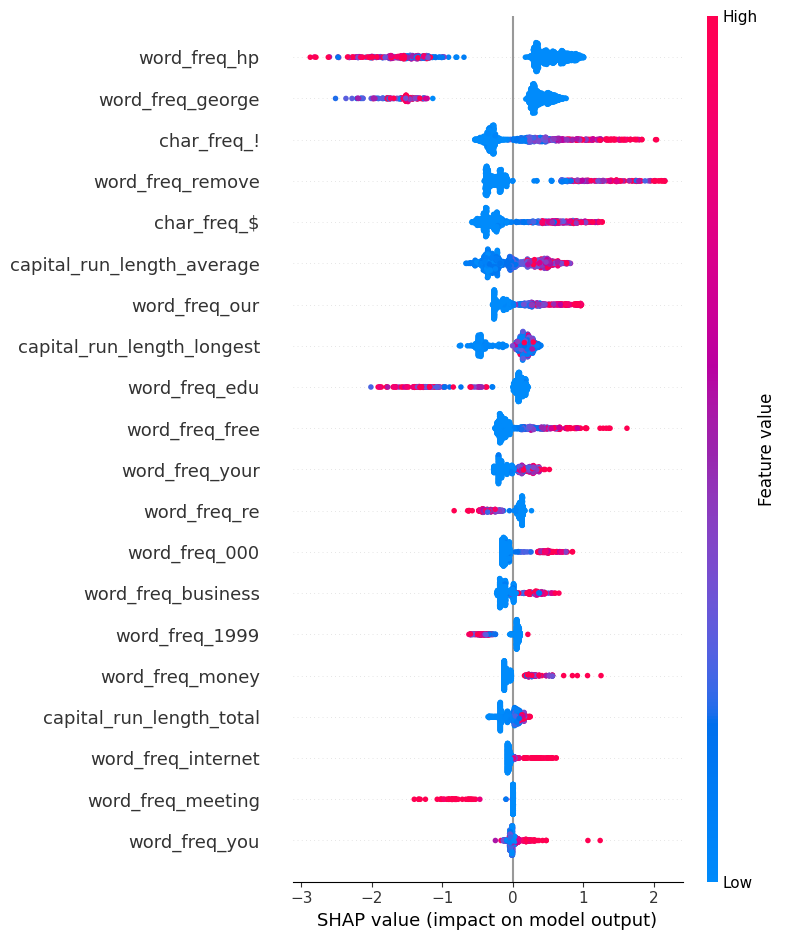

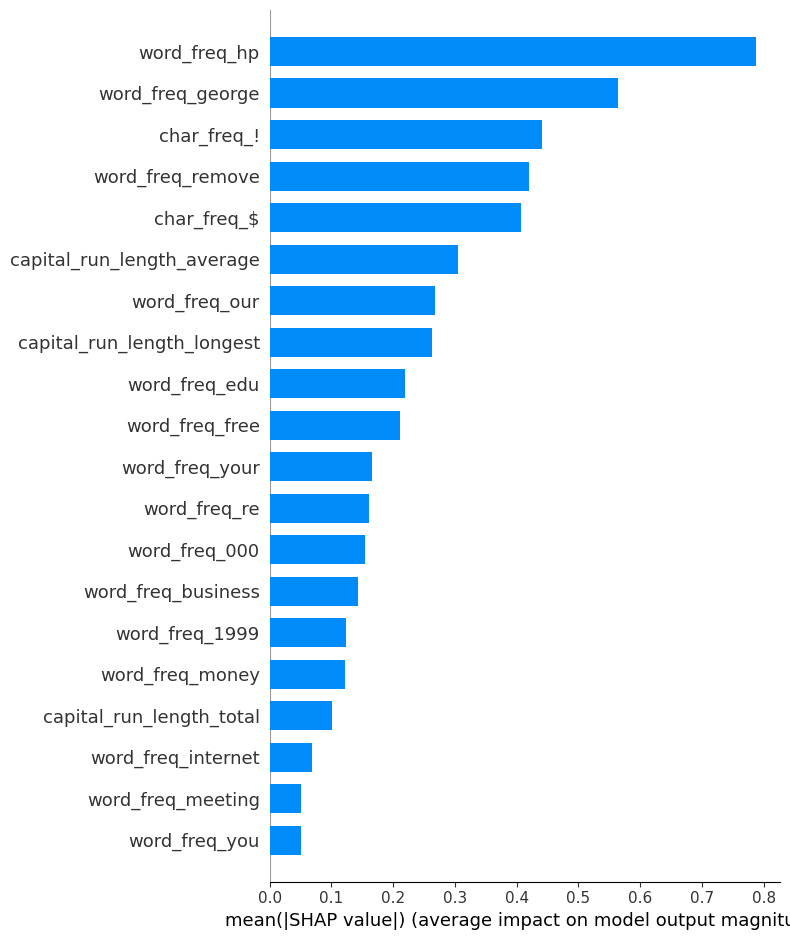

In [53]:
# resumen clásico
shap.summary_plot(shap_values_pos, X_test)

# resumen en barras (importancia media)
shap.summary_plot(shap_values_pos, X_test, plot_type="bar")


In [54]:
def global_shap_importance(explainer_shap, X_test, class_idx=1, n_instances=None):
    """
    Devuelve:
      I          -> importancias globales SHAP (vector)
      order_idx  -> índices de features ordenadas (desc)
    """
    if n_instances is None or n_instances > len(X_test):
        n_instances = len(X_test)

    X_sub = X_test.iloc[:n_instances]

    shap_vals = explainer_shap.shap_values(X_sub)
    if isinstance(shap_vals, list):           # clasificación binaria
        shap_vals = shap_vals[class_idx]      # clase positiva

    I = np.sqrt(np.sum(shap_vals**2, axis=0)) # I_j = sqrt(sum_i shap_ij^2)
    order_idx = np.argsort(-I)                # orden descendente

    return I, order_idx

In [55]:
explainer_shap = shap.TreeExplainer(clf, background)

I_shap, order_idx_shap = global_shap_importance(explainer_shap, X_test)

feature_names = X_test.columns.to_numpy()
for j in order_idx_shap[:10]:
    print(feature_names[j], I_shap[j])

word_freq_hp 28.418652926358984
word_freq_george 21.885740330491842
word_freq_remove 17.851192662976505
char_freq_! 17.042366255475926
char_freq_$ 14.115779579374225
word_freq_edu 12.787150868924611
capital_run_length_average 10.568848555737233
word_freq_our 10.465408061159831
capital_run_length_longest 9.046050973982043
word_freq_free 8.748195408373125


### (b)

Implementar la métrica de inserción (Insertion) para validar la calidad del ranking obtenido en el apartado anterior. Representar la curva de inserción correspondiente.


In [56]:
def insertion_rise(clf, X_test, y_test, order_idx, baseline=None):
    """
    Implementación de la métrica de inserción inspirada en RISE.
    Devuelve la curva de aciertos a medida que se van insertando características.
    """
    Xt = X_test.values
    n_samples, n_features = Xt.shape

    # baseline = vector con valores neutros (media del train normalmente)
    if baseline is None:
        baseline = X_test.mean().values

    # matriz inicial totalmente ocluida
    X_ins = np.tile(baseline, (n_samples, 1))

    accs = []
    accs.append(accuracy_score(y_test, clf.predict(X_ins)))

    # insertar en orden las k características más importantes
    for k in range(1, n_features + 1):
        idx = order_idx[:k]
        X_ins[:, idx] = Xt[:, idx]
        accs.append(accuracy_score(y_test, clf.predict(X_ins)))

    return np.array(accs)

In [57]:
I_shap, order_idx_shap = global_shap_importance(explainer_shap, X_test)
baseline = X_train.mean().values
accs_shap = insertion_rise(clf, X_test, y_test, order_idx_shap, baseline)


In [58]:
I_lime, order_idx_lime = global_lime_importance(clf, explainer_lime, X_test)
accs_lime = insertion_rise(clf, X_test, y_test, order_idx_lime, baseline)


In [59]:
n_features = X_test.shape[1]
order_idx_rand = np.random.permutation(n_features)
accs_rand = insertion_rise(clf, X_test, y_test, order_idx_rand, baseline)


In [60]:
from sklearn.metrics import auc

xs = np.arange(len(accs_lime))
auc_shap = auc(xs, accs_shap)
auc_lime = auc(xs, accs_lime)
auc_rand = auc(xs, accs_rand)


### (c)

Comparar el resultado obtenido con el ranking anterior frente a una selección aleatoria de características. Analizar los resultados y extraer conclusiones.


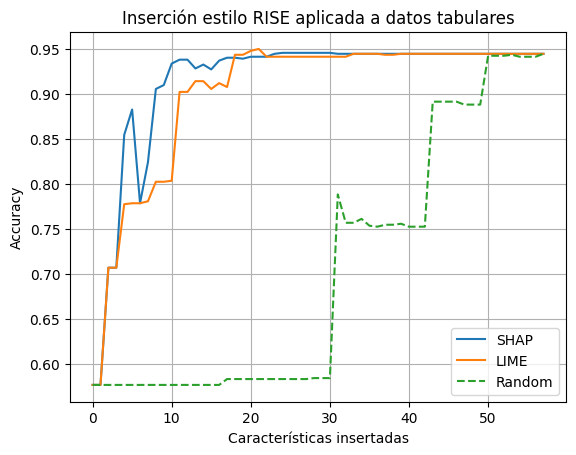

In [61]:
import matplotlib.pyplot as plt

plt.plot(xs, accs_shap, label="SHAP")
plt.plot(xs, accs_lime, label="LIME")
plt.plot(xs, accs_rand, label="Random", linestyle="--")

plt.xlabel("Características insertadas")
plt.ylabel("Accuracy")
plt.title("Inserción estilo RISE aplicada a datos tabulares")
plt.legend()
plt.grid(True)
plt.show()


In [62]:
print("-"*40)
print("shap AUC:", " "*11, auc_shap)
print("lime AUC:"," "*11, auc_lime)
print("baseline(random) AUC:", auc_rand)
print("-"*40)

----------------------------------------
shap AUC:             52.2100977198697
lime AUC:             51.44136807817589
baseline(random) AUC: 40.06786102062975
----------------------------------------


### Análisis y conclusiones del apartado (c)

La comparación entre las curvas de inserción obtenidas mediante SHAP, LIME y una selección aleatoria de características permite validar empíricamente la calidad de los rankings generados por cada método.

Los resultados muestran que los rankings derivados de técnicas de explicabilidad recuperan el rendimiento del modelo de forma más rápida que una selección aleatoria, lo que indica que las características situadas en las primeras posiciones aportan información relevante para la predicción. En particular, el método que presenta una mayor área bajo la curva de inserción (AUC) demuestra una mejor ordenación de las variables según su importancia real para el modelo.

La curva correspondiente a la selección aleatoria actúa como línea base, confirmando que una ordenación sin información previa requiere un mayor número de características para alcanzar niveles similares de precisión. Esta diferencia refuerza la utilidad de las técnicas de explicabilidad no solo como herramientas interpretativas, sino también como mecanismos cuantitativos para validar la fidelidad de las explicaciones generadas.
